In [1]:
from matplotlib import pyplot as plt
import numpy as np
import os
import sys
sys.path.append(os.path.abspath(".."))
from scipy import stats
import pandas as pd
from v1.Utils import ReadTheCsv,ReadTheSpill,append_to_dict
from scipy.optimize import curve_fit

# Load simulation outputs

In [2]:
files = os.listdir("../toy/output/")
#print(files)

outputs = ["toy/output/" + item for item in files if "0p0g.npz" in item]
#print(outputs)

simulation_list = {}

for output in outputs:
    print(output)
    filename   = output.split("/")[2]
    tau        = output.split("_")[1].replace("s","")
    theta      = output.split("_")[3]
    axial      = output.split("_")[5].replace("mK","")
    transverse = output.split("_")[7].replace("mK","")
    append_to_dict(simulation_list, output, float(tau))
    append_to_dict(simulation_list, output, float(theta))
    append_to_dict(simulation_list, output, float(axial))
    append_to_dict(simulation_list, output, float(transverse))

toy/output/tau_78.34s_theta_20_axial_13.36mK_transv_4.50mK_0p0g.npz
toy/output/tau_68.36s_theta_21_axial_16.95mK_transv_2.60mK_0p0g.npz
toy/output/tau_49.08s_theta_139_axial_8.49mK_transv_16.53mK_0p0g.npz
toy/output/tau_36.54s_theta_78_axial_5.25mK_transv_5.50mK_0p0g.npz
toy/output/tau_85.67s_theta_56_axial_11.96mK_transv_4.61mK_0p0g.npz
toy/output/tau_70.13s_theta_61_axial_8.76mK_transv_11.81mK_0p0g.npz
toy/output/tau_22.76s_theta_57_axial_8.28mK_transv_14.53mK_0p0g.npz
toy/output/tau_46.16s_theta_131_axial_3.90mK_transv_2.58mK_0p0g.npz
toy/output/tau_24.32s_theta_151_axial_7.81mK_transv_6.41mK_0p0g.npz
toy/output/tau_81.30s_theta_179_axial_16.56mK_transv_10.12mK_0p0g.npz
toy/output/tau_24.50s_theta_107_axial_12.47mK_transv_7.91mK_0p0g.npz
toy/output/tau_38.00s_theta_58_axial_15.46mK_transv_0.95mK_0p0g.npz
toy/output/tau_72.66s_theta_164_axial_16.41mK_transv_8.92mK_0p0g.npz
toy/output/tau_54.33s_theta_116_axial_4.28mK_transv_15.07mK_0p0g.npz
toy/output/tau_11.50s_theta_70_axial_9.38mK

## Z cuts in 2025 dataset

In [3]:
mirG_center = -415
mirA_center = -671
zmin = mirA_center - 200
zgap_min = mirA_center
zmax = mirG_center + 200
zgap_max = mirG_center
CutsType = "CutsType2"

class Zcuts:
    def __init__(self,a,b, cuts):
        self.mirG_center = a
        self.mirA_center = b
        self.zmin = b - 200
        self.zmax = a + 200
        self.zgap_min = b
        self.zgap_max = a
        self.CutsType = cuts

ZCUTS = Zcuts(-415,-671, CutsType)

# Define the analysis functions for data and simulation

In [4]:
def analysis_function(output):
    file = np.load(output)
    R_array           = file['position']
    Time_Annihilation = file['Time']
    Time_Annihilation = Time_Annihilation[np.isfinite(Time_Annihilation)] # delete atoms that are still trapped, identified with 'nan'
    counts, edges     = np.histogram(Time_Annihilation, bins = 50, range = (0,398.1), density = False)
    return Time_Annihilation, counts, edges

def analysis_data(file, Zcuts):
    # read the file
    dataset = ReadTheCsv(file, "-1", Zcuts.zmin, Zcuts.zmax, ZCUTS.CutsType)
    # Three Segment Ramp Down
    start_mbmf_rampdown0, stop_mbmf_rampdown0 = ReadTheSpill(file,"\"MBMF RampDown\"[0]")
    start_mbmf_rampdown1, stop_mbmf_rampdown1 = ReadTheSpill(file,"\"MBMF RampDown\"[1]")
    start_mbmf_rampdown2, stop_mbmf_rampdown2 = ReadTheSpill(file,"\"MBMF RampDown\"[2]")

    # print(f"{start_mbmf_rampdown0[0] - start_mbmf_rampdown0[0]}; {stop_mbmf_rampdown0[0] - start_mbmf_rampdown0[0]} ")
    # print(f"{start_mbmf_rampdown1[0] - start_mbmf_rampdown0[0]}; {stop_mbmf_rampdown1[0] - start_mbmf_rampdown1[0]} ")
    # print(f"{start_mbmf_rampdown2[0] - start_mbmf_rampdown0[0]}; {stop_mbmf_rampdown2[0] - start_mbmf_rampdown2[0]} ")
    mask      = ((dataset[CutsType] == 1) & 
                (dataset["Z"] > ZCUTS.zmin) & 
                (dataset["Z"] < ZCUTS.zmax))
    mask_time = ((dataset["run time"] > start_mbmf_rampdown0[0]) & 
                 (dataset["run time"] < start_mbmf_rampdown0[0] + 398.1))

    Event_Distribution = dataset["run time"][mask & mask_time].to_numpy() - start_mbmf_rampdown0[0]
    X_distribution = dataset["X"][mask & mask_time].to_numpy()
    Y_distribution = dataset["Y"][mask & mask_time].to_numpy()
    Z_distribution = dataset["Z"][mask & mask_time].to_numpy()

    counts, edges = np.histogram(Event_Distribution, bins = 50, range = (0,398.1), density = False)
    
    return Event_Distribution, counts, edges

# Main Loop LR statitics and visualization

In [5]:
!ls

Comparison.ipynb  Simulated_Scurve.png	data_onlywait.txt
README.txt	  data_onlyramp.txt	simulation_results.png


In [6]:
list_dataset = ["v1/ag14100/ag14100.vertex.csv",
                "v1/ag14106/ag14106.vertex.csv",
                "v1/ag14268/ag14268.vertex.csv",
                "v1/ag14286/ag14286.vertex.csv",
                "v1/ag14308/ag14308.vertex.csv"]

stringa          = ""

dict_runs = {}
for dataset in list_dataset:
    Event_Distribution, counts_obs, edges_obs = analysis_data("../" + dataset, ZCUTS)
    append_to_dict(dict_runs, dataset, counts_obs)

../v1/ag14100/ag14100.vertex.csv
   [26850.997-26862.199]=  11.202s |          "MBMF RampDown"[0]          |    1074       61       53       29      499      396     1214      852     1931         6 

../v1/ag14100/ag14100.vertex.csv
   [26983.913-26995.115]=  11.202s |          "MBMF RampDown"[1]          |    1148       51       53       31      545      420     1317     1208     2690       116 

../v1/ag14100/ag14100.vertex.csv
   [27116.943-27128.146]=  11.202s |          "MBMF RampDown"[2]          |    1104       56       55       42      545      447     1307     1285     2653       142 

../v1/ag14106/ag14106.vertex.csv
   [23785.519-23796.721]=  11.202s |          "MBMF RampDown"[0]          |    1670       81       83       75     1093      800     2652      958     3535         8 

../v1/ag14106/ag14106.vertex.csv
   [23918.318-23929.520]=  11.202s |          "MBMF RampDown"[1]          |    1150       60       61       41      534      426     1250     1245     2562        

In [7]:
for file in outputs:
    if("0p0g" in file):
        print(f"loading {file}")
        data = np.load("../" + file)
        LR_total = data['metric']
        
        try:
            Chisq    = data['Chisq_S']
            print(LR_total)
            append_to_dict(simulation_list, file, float(LR_total))
            append_to_dict(simulation_list, file, Chisq[0])
            append_to_dict(simulation_list, file, Chisq[1])
            append_to_dict(simulation_list, file, Chisq[2])
            append_to_dict(simulation_list, file, Chisq[3])
        except:
            print("Chisq not in archive, skip")
            simulation_list.pop(file, None)
        
        print("-"*16)


loading toy/output/tau_78.34s_theta_20_axial_13.36mK_transv_4.50mK_0p0g.npz
4801.803300569387
----------------
loading toy/output/tau_68.36s_theta_21_axial_16.95mK_transv_2.60mK_0p0g.npz
204081.61224489796
----------------
loading toy/output/tau_49.08s_theta_139_axial_8.49mK_transv_16.53mK_0p0g.npz
Chisq not in archive, skip
----------------
loading toy/output/tau_36.54s_theta_78_axial_5.25mK_transv_5.50mK_0p0g.npz
1407.9230020438463
----------------
loading toy/output/tau_85.67s_theta_56_axial_11.96mK_transv_4.61mK_0p0g.npz
39.95053328483566
----------------
loading toy/output/tau_70.13s_theta_61_axial_8.76mK_transv_11.81mK_0p0g.npz
2985.803625847812
----------------
loading toy/output/tau_22.76s_theta_57_axial_8.28mK_transv_14.53mK_0p0g.npz
5552.834291348602
----------------
loading toy/output/tau_46.16s_theta_131_axial_3.90mK_transv_2.58mK_0p0g.npz
563.6901779911798
----------------
loading toy/output/tau_24.32s_theta_151_axial_7.81mK_transv_6.41mK_0p0g.npz
2910.570385556133
-------

In [8]:
best_for_dataset = ""

for k, v in sorted(simulation_list.items(), key=lambda x: x[1][4])[:1]:
    print(f"{k}: LR = {v[4]}")
    best_for_dataset = k

for k, v in sorted(simulation_list.items(), key=lambda x: x[1][5])[:1]:
    print(f"{k}: Chisq = {v[5]}")

for k, v in sorted(simulation_list.items(), key=lambda x: x[1][6])[:1]:
    print(f"{k}: Chisq = {v[6]}")

for k, v in sorted(simulation_list.items(), key=lambda x: x[1][7])[:1]:
    print(f"{k}: Chisq = {v[7]}")

for k, v in sorted(simulation_list.items(), key=lambda x: x[1][8])[:1]:
    print(f"{k}: Chisq = {v[8]}")

print(best_for_dataset)

toy/output/tau_35.58s_theta_129_axial_3.97mK_transv_4.43mK_0p0g.npz: LR = 23.41290386237435
toy/output/tau_44.88s_theta_178_axial_16.93mK_transv_5.81mK_0p0g.npz: Chisq = 24.307564046031896
toy/output/tau_62.70s_theta_0_axial_9.25mK_transv_14.48mK_0p0g.npz: Chisq = 42.949053710771196
toy/output/tau_62.70s_theta_0_axial_9.25mK_transv_14.48mK_0p0g.npz: Chisq = 45.072017851077014
toy/output/tau_62.70s_theta_0_axial_9.25mK_transv_14.48mK_0p0g.npz: Chisq = 55.756219726921735
toy/output/tau_35.58s_theta_129_axial_3.97mK_transv_4.43mK_0p0g.npz


../v1/ag14100/ag14100.vertex.csv
   [26850.997-26862.199]=  11.202s |          "MBMF RampDown"[0]          |    1074       61       53       29      499      396     1214      852     1931         6 

../v1/ag14100/ag14100.vertex.csv
   [26983.913-26995.115]=  11.202s |          "MBMF RampDown"[1]          |    1148       51       53       31      545      420     1317     1208     2690       116 

../v1/ag14100/ag14100.vertex.csv
   [27116.943-27128.146]=  11.202s |          "MBMF RampDown"[2]          |    1104       56       55       42      545      447     1307     1285     2653       142 

../v1/ag14106/ag14106.vertex.csv
   [23785.519-23796.721]=  11.202s |          "MBMF RampDown"[0]          |    1670       81       83       75     1093      800     2652      958     3535         8 

../v1/ag14106/ag14106.vertex.csv
   [23918.318-23929.520]=  11.202s |          "MBMF RampDown"[1]          |    1150       60       61       41      534      426     1250     1245     2562        

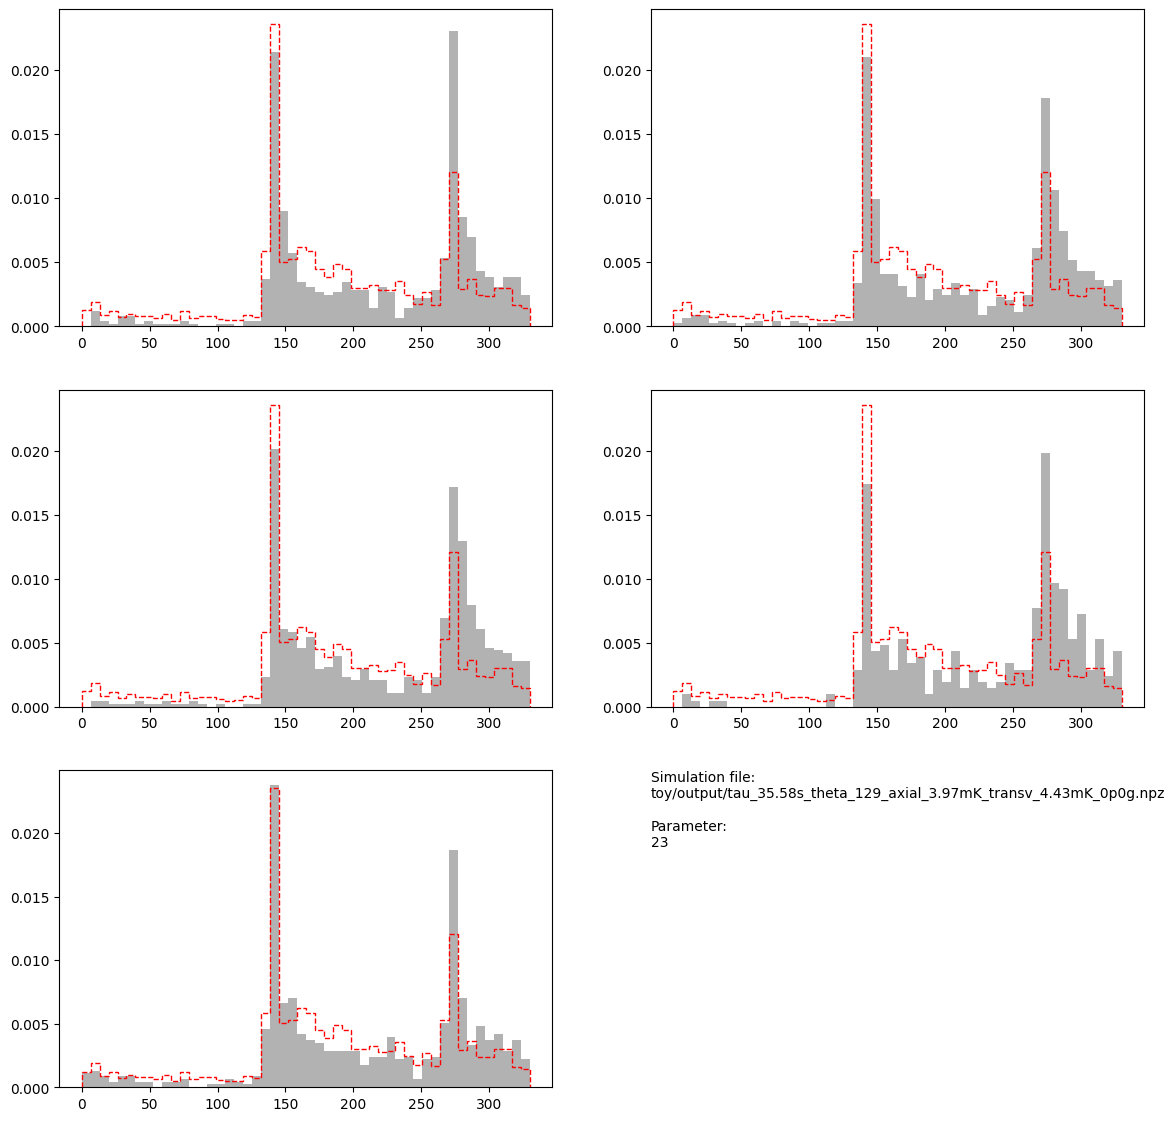

In [9]:
plt.figure(0, figsize=(14,14))

i = 1
for dataset in list_dataset:
    simulation = best_for_dataset
    ax         = plt.subplot(3, 2, i)
    i += 1

    Time_Simulation, counts, edges = analysis_function("../" + simulation)
    Event_Distribution, counts, edges = analysis_data("../" + dataset, ZCUTS)

    ax.hist(Event_Distribution, bins=50, range=(0,330), density=True,
            color="black", alpha=.3)

    ax.hist(Time_Simulation, bins=50, range=(0,330), density=True,
            linestyle="--", histtype="step", color="red")

# ---- ultimo subplot SOLO TESTO ----
ax_text = plt.subplot(3, 2, 6)
ax_text.axis("off")   # niente assi

text = (
    f"Simulation file:\n"
    f"{simulation}\n\n"
    f"Parameter:\n"
    f"{simulation_list[best_for_dataset][4]:.0f}"
)

ax_text.text(
    0.0, 1.0, text,
    transform=ax_text.transAxes,
    fontsize=10,
    verticalalignment="top"
)

plt.savefig("simulation_results.png", bbox_inches="tight")

# heatmap

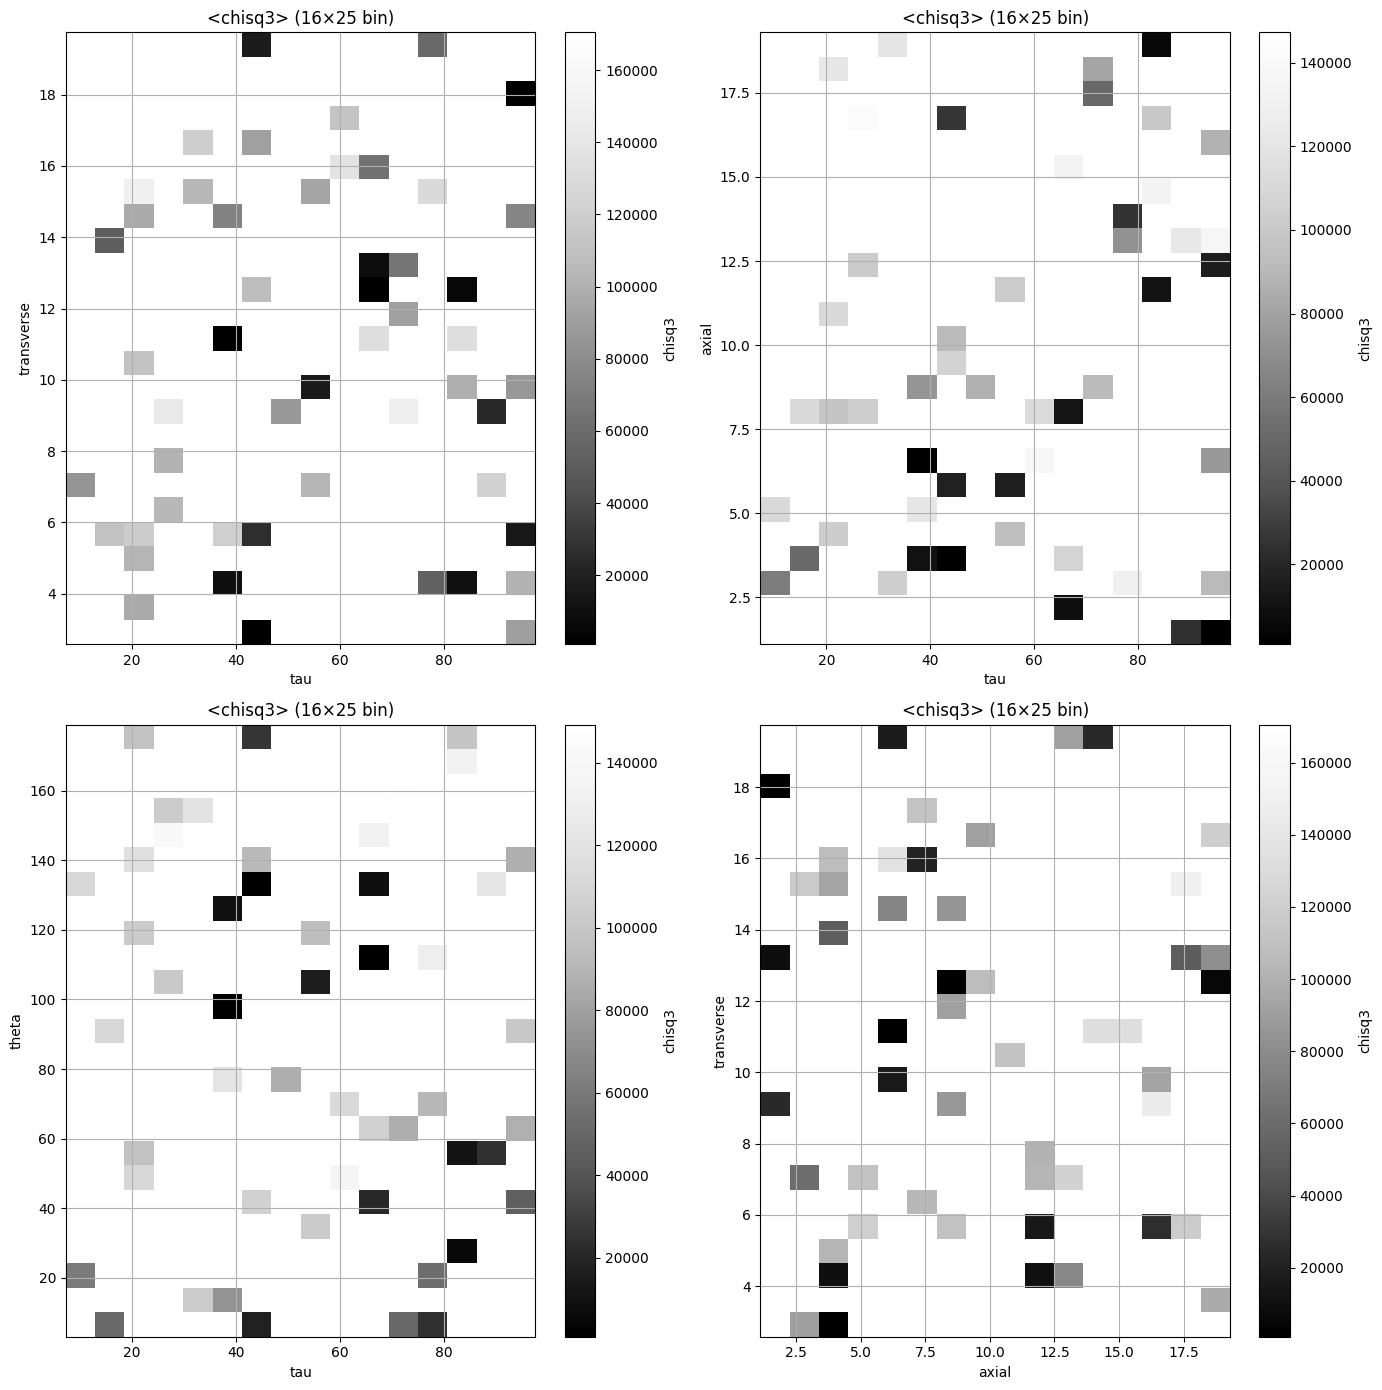

In [10]:
Metric = "chisq3"

df = pd.DataFrame.from_dict(simulation_list, orient='index',
                            columns=["tau", "theta", "axial", "transverse", "LR", "chisq1", "chisq2", "chisq3", "chisq4"])


# Filtra il DataFrame per tau tra 0 e 40
df = df[(df["tau"] >= 0) & (df["tau"] <= 200) & (df["LR"] <= 99999)]

# Crea figura con 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 14))


# Lista delle coppie di parametri da plottare
param_pairs = [
    ("tau", "transverse"),
    ("tau", "axial"),
    ("tau", "theta"),
    ("axial",   "transverse")
]

for i, (x_param, y_param) in enumerate(param_pairs):
    ax = axes[i // 2, i % 2]

    # estrai dati e rimuovi NaN
    mask = (
        np.isfinite(df[x_param]) &
        np.isfinite(df[y_param]) &
        np.isfinite(df[Metric])
    )

    x = df.loc[mask, x_param].values
    y = df.loc[mask, y_param].values
    z = df.loc[mask, Metric].values

    # range fissi
    x_range = (x.min(), x.max())
    y_range = (y.min(), y.max())

    # binning
    LR_sum, xedges, yedges = np.histogram2d(
        x, y,
        bins=[16, 25],
        range=[x_range, y_range],
        weights=z
    )

    counts, _, _ = np.histogram2d(
        x, y,
        bins=[16, 25],
        range=[x_range, y_range]
    )

    # FIX: inizializza LR_mean
    LR_mean = np.full_like(LR_sum, np.nan, dtype=float)
    
    LR_mean[counts != 0] = LR_sum[counts != 0] / counts[counts != 0] #print(LR_mean)
    pcm = ax.pcolormesh(
        xedges,
        yedges,
        LR_mean.T,
        cmap="Greys_r",
        shading="auto"
    )

    ax.set_xlabel(x_param)
    ax.set_ylabel(y_param)
    ax.set_title(f"<{Metric}> (16×25 bin)")
    ax.grid(True)

    fig.colorbar(pcm, ax=ax, label=Metric)

#axes[1, 1].axis("off")
plt.tight_layout()
plt.show()


# ===> ANALYZE SCURVE

In [11]:
from toy.UTILS import Zmin, Zmax, Zmid, zacceptance_min, zacceptance_max

/home/adriano/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [12]:
Tramp1     = 11.2
wait_ramp1 = 121.5 + Tramp1

Tramp2     = 11.2 + wait_ramp1
wait_ramp2 = 121.5 + Tramp2

Tramp3     = 11.2 + wait_ramp2
wait_ramp3 = 121.5 + Tramp3

In [13]:
# Make Plot Nicer
def plotter_nicer():
    plt.ylabel(r"S = $\frac{N_{\downarrow} - N_{\uparrow}}{N_{\uparrow} + N_{\downarrow}}$", fontsize = 18, loc = "top")
    plt.xlabel("bias", loc = 'right', fontsize = 18)
    
    plt.grid()
    plt.minorticks_on()
    plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
    plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia
    plt.ylim(-1.1,1.1)
    #plt.xlim(-3, 3)
    
    plt.axhline(0.0, linestyle = "-",  color = "red",    alpha = 1, linewidth = 0.75)
    #plt.text(-2.9, 0.005, "balance escape 0.0", color = "red")
    plt.axvline(0,   linestyle = "-",  color = "black",  linewidth = 0.75)
    #plt.axvline(-2,   linestyle = "-",  color = "black",  linewidth = 0.75)
    plt.axvline(-1,  linestyle = "-", color = "maroon", linewidth = 0.75)
    plt.text( -1. + 0.02, 0.65, "-1.0g bias", rotation = 90, color = "maroon")

In [14]:
def get_annihilations(output, bias):
    f = np.load(output)
    R = f["position"]
    t = f["Time"]

    m = np.isfinite(t)
    z = R[m, 2]
    t = t[m]

    z_up   = zacceptance_max - 1e-3
    z_down = zacceptance_min + 1e-3

    def counts(tmin=None, tmax=None):
        mt = np.ones_like(t, dtype=bool)
        if tmin is not None: mt &= (t > tmin)
        if tmax is not None: mt &= (t < tmax)
        nup   = np.sum((z >= z_up)   & mt)
        ndown = np.sum((z <= z_down) & mt)
        return nup, ndown

    def asym(nup, ndown):
        n = nup + ndown
        if n == 0:
            return np.nan, np.nan
        A = (ndown - nup) / n
        dA = np.sqrt(np.abs(1 - A**2) / n)
        return A, dA

    # totale (t finito)
    A, dA = asym(*counts())

    # segmenti: (tmin, tmax)
    windows = {
        "A0":  (0,        Tramp1),
        "A0b": (Tramp1,   wait_ramp1),
        "A1":  (wait_ramp1, Tramp2),
        "A1b": (Tramp2,   wait_ramp2),
        "A2":  (wait_ramp2, Tramp3),
        "A2b": (Tramp3,   None),
    }

    (A0, dA0)   = asym(*counts(*windows["A0"]))
    (A0b, dA0b) = asym(*counts(*windows["A0b"]))
    (A1, dA1)   = asym(*counts(*windows["A1"]))
    (A1b, dA1b) = asym(*counts(*windows["A1b"]))
    (A2, dA2)   = asym(*counts(*windows["A2"]))
    (A2b, dA2b) = asym(*counts(*windows["A2b"]))

    return [A0, A1, A2, A, A0b, A1b, A2b], [dA0, dA1, dA2, dA, dA0b, dA1b, dA2b]

# Plot the best Scurve

In [36]:
# x[1][4] : LR
# x[1][5] : 2 segment
# x[1][6] : 3 segment
# x[1][7] : 2 segment boiloff
# x[1][8] : 3 segment boiloff

best_sim = (sorted(simulation_list.items(), key=lambda x: x[1][8])[:1])[0][0].split("/")[2].replace('0p0g.npz','')
metric   = (sorted(simulation_list.items(), key=lambda x: x[1][8])[:1])
print(best_sim, metric[0][1][6])

tau_62.70s_theta_0_axial_9.25mK_transv_14.48mK_ 42.949053710771196


In [37]:
def linear(x,m,q):
    return m*x + q

def shift(m,q):
    return -q/m


cols = [
    "run", "bias", "type_ramp",
    "segment1", "err_segment1",
    "segment2", "err_segment2",
    "segment3", "err_segment3",
    "segment4", "err_segment4"
]

df_onlyramps = pd.read_csv(
    "data_onlyramp.txt",
    comment="#",
    sep=r"\s+",
    names=cols
)

df_onlywait = pd.read_csv(
    "data_onlywait.txt",
    comment="#",
    sep=r"\s+",
    names=cols
)


##################################################
# SIMULATION, Load the Data

files = os.listdir("../toy/output/")

# get all the simulation files
outputs = ["../toy/output/" + item for item in files if ".npz" in item if best_sim in item]
print("Outputs files: \n", outputs)

simulation_dataset = {}

# create containers for Asymmetries
A0,   A1,  A2, At  = [],[],[],[]
A0b,   A1b,  A2b   = [],[],[]
dA0, dA1, dA2, dAt = [],[],[],[]
dA0b, dA1b, dA2b   = [],[],[]

biases = []

# get the asymetries for each individual segment
for output in outputs:
    print("-"*20)
    bias = output.split("_")[8].replace(".npz","") # get the bias
    A, dA = get_annihilations(output, bias)

    A0.append(A[0])
    A1.append(A[1])
    A2.append(A[2])
    At.append(A[3])
    A0b.append(A[4])
    A1b.append(A[5])
    A2b.append(A[6])
    
    dA0.append(dA[0])
    dA1.append(dA[1])
    dA2.append(dA[2])
    dAt.append(dA[3])
    dA0b.append(dA[4])
    dA1b.append(dA[5])
    dA2b.append(dA[6])

    #print(bias, f"{A[0]:.2}",  f"{dA[0]:.2f}")
    #print(bias, f"{A[1]:.2f}", f"{dA[1]:.2f}")
    #print(bias, f"{A[2]:.2f}", f"{dA[2]:.2f}")

    biases.append( float( bias.replace("p",".").replace("g","") ))

biases = np.array(biases)
#print(biases)

At = np.array(At)
dAt = np.array(dAt)
A0 = np.array(A0)
A1 = np.array(A1)
A2 = np.array(A2)
A0b = np.array(A0)
A1b = np.array(A1b)
A2b = np.array(A2b)
A0 = np.array(A0)
dA1 = np.array(dA1)
dA2 = np.array(dA2)
dA0b = np.array(dA0)
dA1b = np.array(dA1b)
dA2b = np.array(dA2b)

print(biases)


Outputs files: 
 ['../toy/output/tau_62.70s_theta_0_axial_9.25mK_transv_14.48mK_-0p37g.npz', '../toy/output/tau_62.70s_theta_0_axial_9.25mK_transv_14.48mK_-0p5g.npz', '../toy/output/tau_62.70s_theta_0_axial_9.25mK_transv_14.48mK_0p25g.npz', '../toy/output/tau_62.70s_theta_0_axial_9.25mK_transv_14.48mK_0p75g.npz', '../toy/output/tau_62.70s_theta_0_axial_9.25mK_transv_14.48mK_-1p25g.npz', '../toy/output/tau_62.70s_theta_0_axial_9.25mK_transv_14.48mK_-0p75g.npz', '../toy/output/tau_62.70s_theta_0_axial_9.25mK_transv_14.48mK_-0p25g.npz', '../toy/output/tau_62.70s_theta_0_axial_9.25mK_transv_14.48mK_1p25g.npz', '../toy/output/tau_62.70s_theta_0_axial_9.25mK_transv_14.48mK_0p5g.npz', '../toy/output/tau_62.70s_theta_0_axial_9.25mK_transv_14.48mK_0p0g.npz']
--------------------
--------------------
--------------------
--------------------
--------------------
--------------------
--------------------
--------------------
--------------------
--------------------
[-0.37 -0.5   0.25  0.75 -1.25

In [38]:
from scipy.interpolate import CubicSpline
idx = np.argsort(biases)

# Spline of simulation
if not np.isnan(A1[idx]).any():
    simulation_2nd = CubicSpline(biases[idx], A1[idx])
if not np.isnan(A2[idx]).any():
    simulation_3rd = CubicSpline(biases[idx], A2[idx])
if not np.isnan(A1b[idx]).any():
    simulation_2nd_boiloff = CubicSpline(biases[idx], A1b[idx])
if not np.isnan(A2b[idx]).any():
    simulation_3rd_boiloff = CubicSpline(biases[idx], A2b[idx])

def chisq_mean(simulation, x, y, dy):
    x  = np.asarray(x, float)
    y  = np.asarray(y, float)
    dy = np.asarray(dy, float)

    yhat = simulation(x)
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(dy) & (dy > 0)
    return np.sum(((y[mask] - yhat[mask]) / dy[mask])**2)

def compute_segment_chisq(df, segment, simulation):
    mask = df["type_ramp"] == "short"

    popt, _ = curve_fit(
        linear,
        df["bias"][mask],
        df[f"segment{segment}"][mask]
    )

    x = df["bias"][mask] - shift(popt[0], popt[1])
    y = df[f"segment{segment}"][mask]
    dy =  df[f"err_segment{segment}"][mask]

    return chisq_mean(simulation, x, y, dy)

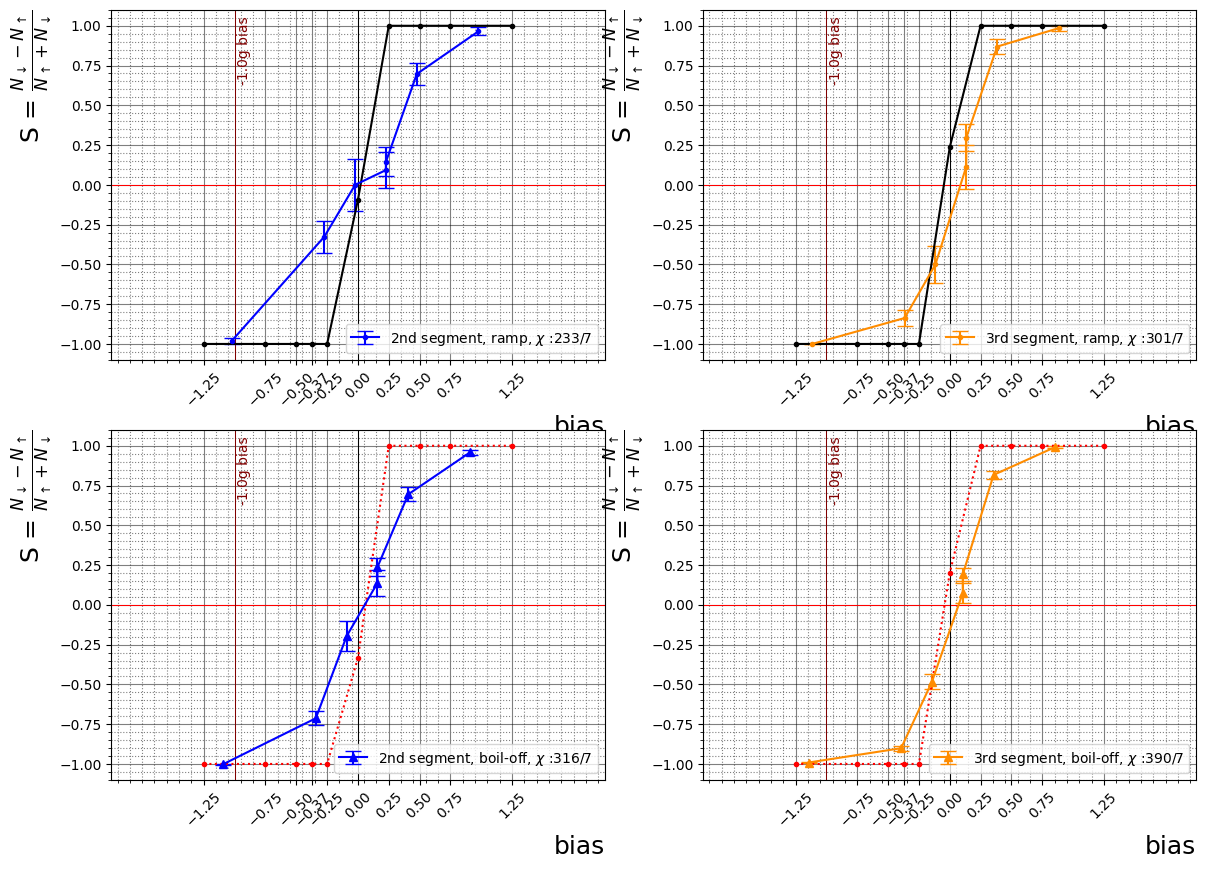

In [39]:
idx = np.argsort(biases)
plt.figure(1, figsize = (14,10))

plt.subplot(2,2,1)
#plt.suptitle("2nd segment")
# SIMULATION
plotter_nicer()
plt.errorbar(biases[idx], simulation_2nd(biases[idx]),  marker = ".", linestyle = "-", markersize = 6,color = "black", capsize = 4)
# DATASET 2025
mask = df_onlyramps['type_ramp' ] == 'short'
popt,pcovm = curve_fit(linear, df_onlyramps['bias'][mask] , df_onlyramps['segment2'][mask])
plt.errorbar(df_onlyramps['bias'][mask] - shift(popt[0], popt[1]), 
             df_onlyramps['segment2'][mask],
             df_onlyramps['err_segment2'][mask],
             linestyle = "-", 
             markersize = 6 ,
             marker = '.', 
             capsize = 6,
             color = "blue", 
             label = f"2nd segment, ramp, $\chi$ :{compute_segment_chisq(df_onlyramps,  2, simulation_2nd):.0f}/{mask.sum()}")

plt.xticks(biases[idx], rotation = 45, fontsize = 10)
plt.xlim(-2,+2)
plt.legend()

plt.subplot(2,2,2)
# SIMULATION
plotter_nicer()
plt.errorbar(biases[idx], simulation_3rd(biases[idx]),  marker = ".", linestyle = "-", markersize = 6, color = "black", capsize = 4)
popt,pcovm = curve_fit(linear, df_onlyramps['bias'][mask] , df_onlyramps['segment3'][mask])
plt.errorbar(df_onlyramps['bias'][mask] - shift(popt[0], popt[1]), 
             df_onlyramps['segment3'][mask],
             df_onlyramps['err_segment3'][mask], 
             linestyle = "-", 
             markersize = 6 ,
             marker = '.', 
             capsize = 6,
             color = "darkorange", 
             label = f"3rd segment, ramp, $\chi$ :{compute_segment_chisq(df_onlyramps,  3, simulation_3rd):.0f}/{mask.sum()}")
plt.xticks(biases[idx], rotation = 45, fontsize = 10)
plt.xlim(-2,+2)
plt.legend()


plt.subplot(2,2,3)
# SIMULATION
plt.errorbar(biases[idx], simulation_2nd_boiloff(biases[idx]), marker = ".", linestyle = "dotted", markersize = 6,color = "red", capsize = 4)
#dataset with boil-off
mask = df_onlywait['type_ramp' ] == 'short'
popt,pcovm = curve_fit(linear, df_onlywait['bias'][mask] , df_onlywait['segment2'][mask])
plt.errorbar(df_onlywait['bias'][mask] - shift(popt[0], popt[1]), 
             df_onlywait['segment2'][mask],
             df_onlywait['err_segment2'][mask],
             linestyle = "-", 
             markersize = 6 ,
             marker = '^',
             capsize = 6,
             color = "blue", 
             label = f"2nd segment, boil-off, $\chi$ :{compute_segment_chisq(df_onlywait,  2, simulation_2nd_boiloff):.0f}/{mask.sum()}")
plotter_nicer()
plt.xticks(biases[idx], rotation = 45, fontsize = 10)
plt.xlim(-2,+2)
plt.legend()

plt.subplot(2,2,4)
# SIMULATION
plt.errorbar(biases[idx], simulation_3rd_boiloff(biases[idx]), marker = ".", linestyle = "dotted", markersize = 6,  color = "red",capsize = 4)
#dataset with boil-off
popt,pcovm = curve_fit(linear, df_onlywait['bias'][mask] , df_onlywait['segment3'][mask])
plt.errorbar(df_onlywait['bias'][mask] - shift(popt[0], popt[1]), 
             df_onlywait['segment3'][mask],
             df_onlywait['err_segment3'][mask],
             linestyle = "-", 
             markersize = 6 ,
             marker = '^',
             capsize = 6,
             color = "darkorange", 
             label = f"3rd segment, boil-off, $\chi$ :{compute_segment_chisq(df_onlywait,  3, simulation_3rd_boiloff):.0f}/{mask.sum()}")


plotter_nicer()
plt.xticks(biases[idx], rotation = 45, fontsize = 10)
plt.xlim(-2,+2)
plt.legend()

#plt.savefig(f"output/figures/output_scurve/{outputfile}_Scurve.png", bbox_inches = 'tight')

# Compute the Metric, Chiquare between data and simulation

In [40]:
from scipy.interpolate import CubicSpline
idx = np.argsort(biases)

# Spline of simulation
simulation_2nd = CubicSpline(biases[idx], A1[idx])

simulation_3rd = CubicSpline(biases[idx], A2[idx])

simulation_2nd_boiloff = CubicSpline(biases[idx], A1b[idx])

simulation_3rd_boiloff = CubicSpline(biases[idx], A2b[idx])

print(compute_segment_chisq(df_onlyramps, 2, simulation_2nd))
print(compute_segment_chisq(df_onlyramps, 3, simulation_3rd))

print(compute_segment_chisq(df_onlywait,  2, simulation_2nd_boiloff))
print(compute_segment_chisq(df_onlywait,  3, simulation_3rd_boiloff))

232.94661331135282
300.6433759753984
315.5041249575391
390.2935380884521
